
# Fitting the xG model


In [34]:
# importing necessary libraries
import pandas as pd
import numpy as np
import json
# plotting
import matplotlib.pyplot as plt
from mplsoccer import VerticalPitch
# statistical fitting of models
import statsmodels.api as sm
import statsmodels.formula.api as smf
#opening data
import os
import pathlib
import warnings 

pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore')

## Opening data
To fit the xG model we will use Wyscout data. To meet file size requirements of Github, we have to open it from different files,
but you can open the file locally from the directory you saved it in.



In [35]:
    #load data - store it in train dataframe
train = pd.DataFrame()
for i in range(13):
    file_name = 'events_England_' + str(i+1) + '.json'
    path = os.path.join(str(pathlib.Path().resolve()), 'data', file_name)
    with open(path) as f:
        data = json.load(f)
    train = pd.concat([train, pd.DataFrame(data)])

## Preparing  data
Exepcted goals model is build using only shots, so we keep only those actions which *subEventName* was *Shot*. Note that this way
penalties are excluded which wouldn't be a case if we used only *eventName*. Then, we store the coordinates of a shot transformed
to 105 x 68 pitch. Also, we treat the goal as x = 0. Created *C* is an auxillary variable to help us calculate distance and angle.
It is the distance from a point to the horizontal line through the middle of the pitch. We calculate the distance to the goal as the
distance on Euclidean plane (see [Distance in R2](https://www.youtube.com/watch?v=Qkpr30zSpiE&t=297s&ab_channel=FriendsofTracking)).
and angle using the formula from [The Geometry of Shooting](https://soccermatics.medium.com/the-geometry-of-shooting-ae7a67fdf760).
Moreover, we need an information if a goal was scored. It can be found in the *tags* column - if in this column exists {*id*: *101*}.



In [36]:
shots = train.loc[train['subEventName'] == 'Shot']
#get shot coordinates as separate columns
shots["X"] = shots.positions.apply(lambda cell: (100 - cell[0]['x']) * 105/100)
shots["Y"] = shots.positions.apply(lambda cell: cell[0]['y'] * 68/100)
shots["C"] = shots.positions.apply(lambda cell: abs(cell[0]['y'] - 50) * 68/100)
#calculate distance and angle 
shots["Distance"] = np.sqrt(shots["X"]**2 + shots["C"]**2)
shots["Angle"] = np.where(np.arctan(7.32 * shots["X"] / (shots["X"]**2 + shots["C"]**2 - (7.32/2)**2)) > 0, np.arctan(7.32 * shots["X"] /(shots["X"]**2 + shots["C"]**2 - (7.32/2)**2)), np.arctan(7.32 * shots["X"] /(shots["X"]**2 + shots["C"]**2 - (7.32/2)**2)) + np.pi)
#if you ever encounter problems (like you have seen that model treats 0 as 1 and 1 as 0) while modelling - change the dependant variable to object 
shots["Goal"] = shots.tags.apply(lambda x: 1 if {'id':101} in x else 0)

## Fitting logistic regression and finding best parameters
The best parameters are those which maximize the log-likelihood.



                 Generalized Linear Model Regression Results                  
Dep. Variable:                   Goal   No. Observations:                 8451
Model:                            GLM   Df Residuals:                     8449
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2561.2
Date:                Tue, 24 Mar 2026   Deviance:                       5122.5
Time:                        07:57:23   Pearson chi2:                 7.96e+03
No. Iterations:                     6   Pseudo R-squ. (CS):            0.07609
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.5248      0.074    -47.517      0.0

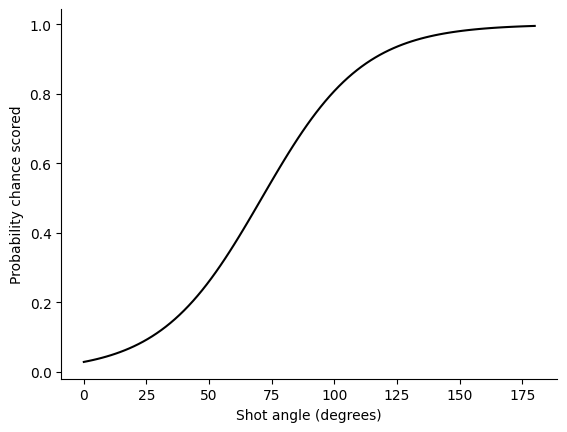

In [37]:
#create model
test_model = smf.glm(formula="Goal ~ Angle" , data=shots, 
                           family=sm.families.Binomial()).fit()
print(test_model.summary())
#get params        
b=test_model.params
b_angle = b   # save angle-only coefficients for later comparisons
print(b)
#calculate xG
midangle = np.linspace(0,180,100)
xGprob = 1/(1+np.exp(-(b['Intercept']+b['Angle']*midangle*np.pi/180))) 
fig, ax = plt.subplots()
#plot line
ax.plot(midangle, xGprob, linestyle='solid', color='black')
#make legend
ax.set_ylabel('Probability chance scored')
ax.set_xlabel("Shot angle (degrees)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

# Build a 2D probability map for the angle-only model
pgoal_2d_angle = np.zeros((68, 68))
for x in range(68):
    for y in range(68):
        a = np.arctan(7.32 * x / (x**2 + abs(y - 68/2)**2 - (7.32/2)**2))
        if a < 0:
            a = np.pi + a
        bsum = b_angle['Intercept'] + b_angle['Angle'] * a
        pgoal_2d_angle[x, y] = 1 / (1 + np.exp(-bsum))


## Adding distance to the model
To our model we can add more variables than only one. We can try adding distance to goal and see if it improves
our predictions.



                 Generalized Linear Model Regression Results                  
Dep. Variable:                   Goal   No. Observations:                 8451
Model:                            GLM   Df Residuals:                     8448
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2501.6
Date:                Tue, 24 Mar 2026   Deviance:                       5003.2
Time:                        07:57:23   Pearson chi2:                 9.42e+03
No. Iterations:                     6   Pseudo R-squ. (CS):            0.08904
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.2099      0.221     -5.466      0.0

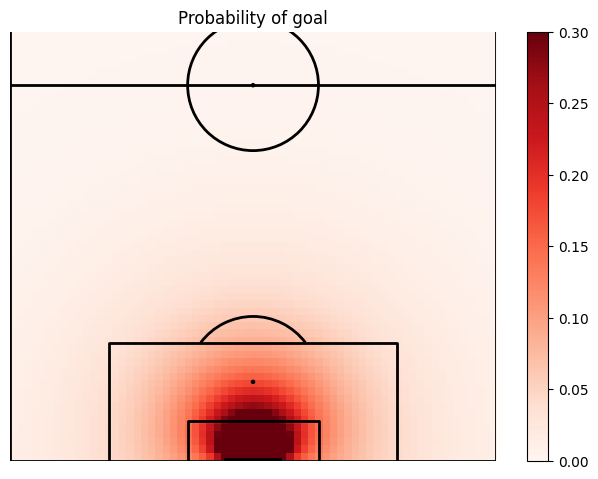

In [38]:
#creating extra variables
shots["X2"] = shots['X']**2
shots["C2"] = shots['C']**2
shots["AX"]  = shots['Angle']*shots['X']

# list the model variables you want here
model_variables = ['Angle','Distance'] #,'X','C', "X2", "C2", "AX"]
model=''
for v in model_variables[:-1]:
    model = model  + v + ' + '
model = model + model_variables[-1]

#fit the model
test_model = smf.glm(formula="Goal ~ " + model, data=shots,
                           family=sm.families.Binomial()).fit()
#print summary
print(test_model.summary())
b=test_model.params
b_full = b   # save full model coefficients for later comparisons

#return xG value for more general model
def calculate_xG(sh):
   bsum=b['Intercept']
   for v in model_variables:
       bsum=bsum+b[v]*sh[v]
   xG = 1/(1+np.exp(-bsum))
   return xG

#add an xG to my dataframe
xG=shots.apply(calculate_xG, axis=1)
shots = shots.assign(xG=xG)

#Create a 2D map of xG
pgoal_2d=np.zeros((68,68))
for x in range(68):
    for y in range(68):
        sh=dict()
        a = np.arctan(7.32 *x /(x**2 + abs(y-68/2)**2 - (7.32/2)**2))
        if a<0:
            a = np.pi + a
        sh['Angle'] = a
        sh['Distance'] = np.sqrt(x**2 + abs(y-68/2)**2)
        sh['D2'] = x**2 + abs(y-68/2)**2
        sh['X'] = x
        sh['AX'] = x*a
        sh['X2'] = x**2
        sh['C'] = abs(y-68/2)
        sh['C2'] = (y-68/2)**2

        pgoal_2d[x,y] =  calculate_xG(sh)

pgoal_2d_full = pgoal_2d   # alias for later comparisons

#plot pitch
pitch = VerticalPitch(line_color='black', half = True, pitch_type='custom', pitch_length=105, pitch_width=68, line_zorder = 2)
fig, ax = pitch.draw()
#plot probability
pos = ax.imshow(pgoal_2d, extent=[-1,68,68,-1], aspect='auto',cmap=plt.cm.Reds,vmin=0, vmax=0.3, zorder = 1)
fig.colorbar(pos, ax=ax)
#make legend
ax.set_title('Probability of goal')
plt.xlim((0,68))
plt.ylim((0,60))
plt.gca().set_aspect('equal', adjustable='box')
plt.show()


## Contribution plot
Each shot's contribution of feature $j$ is $\beta_j \cdot (x_{ij} - \mu_j)$, where $\mu_j$ is the mean of that feature. The plot below shows these contributions in the style of a SHAP summary plot.

In [39]:

# --- Contribution plot (SHAP-style, using beta_j * (x_ij - mu_j)) ---
# Colour = feature value (z-score): red = high, blue = low
# Hover shows actual Angle (degrees) and Distance for each shot

import plotly.graph_objects as go

CLAMP = 2.0   # colour scale spans ±2 std devs for clear contrast

# Deduplicate model_variables while preserving order
seen = []
for v in model_variables:
    if v not in seen:
        seen.append(v)
plot_variables = seen
feature_labels = plot_variables

# Sample 100 shots at random for the plot
shots_sample = shots.sample(n=100, random_state=42).reset_index(drop=True)

n_shots = len(shots_sample)
n_feat  = len(plot_variables)

# Compute contributions and z-scored feature values (for colouring)
contributions = np.zeros((n_shots, n_feat))
feat_norm     = np.zeros((n_shots, n_feat))

for j, v in enumerate(plot_variables):
    mu_j  = shots[v].mean()
    std_j = shots[v].std()
    contributions[:, j] = b[v] * (shots_sample[v].values - mu_j)
    feat_norm[:, j]     = (shots_sample[v].values - mu_j) / std_j  # z-score

angle_deg = shots_sample['Angle'].values * 180 / np.pi
dist_m    = shots_sample['Distance'].values

order = np.argsort(np.mean(np.abs(contributions), axis=0))
rng   = np.random.default_rng(42)

fig = go.Figure()

for row_idx, j in enumerate(order):
    v        = plot_variables[j]
    y_jitter = rng.uniform(-0.35, 0.35, size=n_shots)

    hover = [
        f"<b>{v}</b><br>"
        f"Angle: {angle_deg[i]:.1f}\u00b0<br>"
        f"Distance: {dist_m[i]:.1f} m<br>"
        f"Contribution: {contributions[i, j]:.3f}"
        for i in range(n_shots)
    ]

    # Only the last (topmost) trace carries the colourbar
    show_cb = (row_idx == n_feat - 1)
    marker_opts = dict(
        color=np.clip(feat_norm[:, j], -CLAMP, CLAMP),
        colorscale='RdBu',
        reversescale=True,   # high value → red, low value → blue
        cmin=-CLAMP,
        cmax=CLAMP,
        opacity=0.7,
        size=6,
        showscale=show_cb,
    )
    if show_cb:
        marker_opts['colorbar'] = dict(
            title='Feature value<br>(std devs)',
            tickvals=[-2, -1, 0, 1, 2],
            ticktext=['\u22122\u03c3', '\u22121\u03c3', 'Mean', '+1\u03c3', '+2\u03c3'],
        )

    fig.add_trace(go.Scatter(
        x=contributions[:, j],
        y=row_idx + y_jitter,
        mode='markers',
        marker=marker_opts,
        text=hover,
        hovertemplate='%{text}<extra></extra>',
        showlegend=False,
    ))

fig.update_layout(
    width=750, height=380,
    title='Feature contributions to xG \u2013 100 random shots',
    xaxis=dict(
        title='Contribution to log-odds of goal: \u03b2<sub>j</sub>(x<sub>ij</sub> \u2212 \u03bc<sub>j</sub>)',
        zeroline=True, zerolinecolor='black', zerolinewidth=1,
        showgrid=False,
    ),
    yaxis=dict(
        tickmode='array',
        tickvals=list(range(n_feat)),
        ticktext=[feature_labels[j] for j in order],
        showgrid=False,
    ),
    plot_bgcolor='white',
    margin=dict(l=80, r=120, t=60, b=60),
)
fig.show()


# Effect on odds of a 5-degree angle increase or 10 m distance increase

For a logistic regression, changing feature $j$ by $\Delta x$ multiplies the odds by $\exp(\beta_j \cdot \Delta x)$.
Odds ratio > 1 → odds increase (better chance of scoring); < 1 → odds decrease.

The table below shows the effect for both the **angle-only model** and the **angle + distance model**.


In [43]:
delta_angle_rad = 5 * np.pi / 180   # 5 degrees in radians
delta_distance  = 2.0              # 2 metres

model_specs = [
    ('Angle-only model',       b_angle, [('Angle', delta_angle_rad, '+5\u00b0 angle')]),
    ('Angle + Distance model', b_full,  [('Angle',    delta_angle_rad, '+5\u00b0 angle'),
                                          ('Distance', delta_distance,  '+2 m distance')]),
]

for model_name, coefs, changes in model_specs:
    print(f'\n{"="*55}')
    print(f'  {model_name}')
    print(f'{"="*55}')
    results = []
    for var, delta, label in changes:
        if var not in coefs.index:
            continue
        log_odds_change = coefs[var] * delta
        odds_ratio      = np.exp(log_odds_change)
        pct_change      = (odds_ratio - 1) * 100
        direction       = 'increases' if odds_ratio > 1 else 'decreases'
        results.append({
            'Change':             label,
            'Coefficient \u03b2': round(coefs[var], 4),
            '\u0394 log-odds':    round(log_odds_change, 4),
            'Odds ratio':         round(odds_ratio, 4),
            '% change in odds':   f'{pct_change:+.1f}%',
            'Direction':          direction,
        })
    df = pd.DataFrame(results).set_index('Change')
    print(df.to_string())
    print()
    for r in results:
        print(f"  {r['Change']:20s}  \u2192  "
              f"odds ratio = {r['Odds ratio']:.4f}  "
              f"({r['% change in odds']}, {r['Direction']})")



  Angle-only model
           Coefficient β  Δ log-odds  Odds ratio % change in odds  Direction
Change                                                                      
+5° angle         2.8436      0.2482      1.2817           +28.2%  increases

  +5° angle             →  odds ratio = 1.2817  (+28.2%, increases)

  Angle + Distance model
               Coefficient β  Δ log-odds  Odds ratio % change in odds  Direction
Change                                                                          
+5° angle             1.1835      0.1033      1.1088           +10.9%  increases
+2 m distance        -0.0978     -0.1957      0.8223           -17.8%  decreases

  +5° angle             →  odds ratio = 1.1088  (+10.9%, increases)
  +2 m distance         →  odds ratio = 0.8223  (-17.8%, decreases)


## Probability change heatmap from a reference point (final third)

The maps below show how the **probability of scoring changes relative to a chosen reference position** within 10 m of that point, for both models.

- **Blue** = higher probability of scoring than the reference point
- **Red** = lower probability of scoring than the reference point
- **White** = same probability (or outside the 10 m radius)
- **Cross ✕** marks the reference position


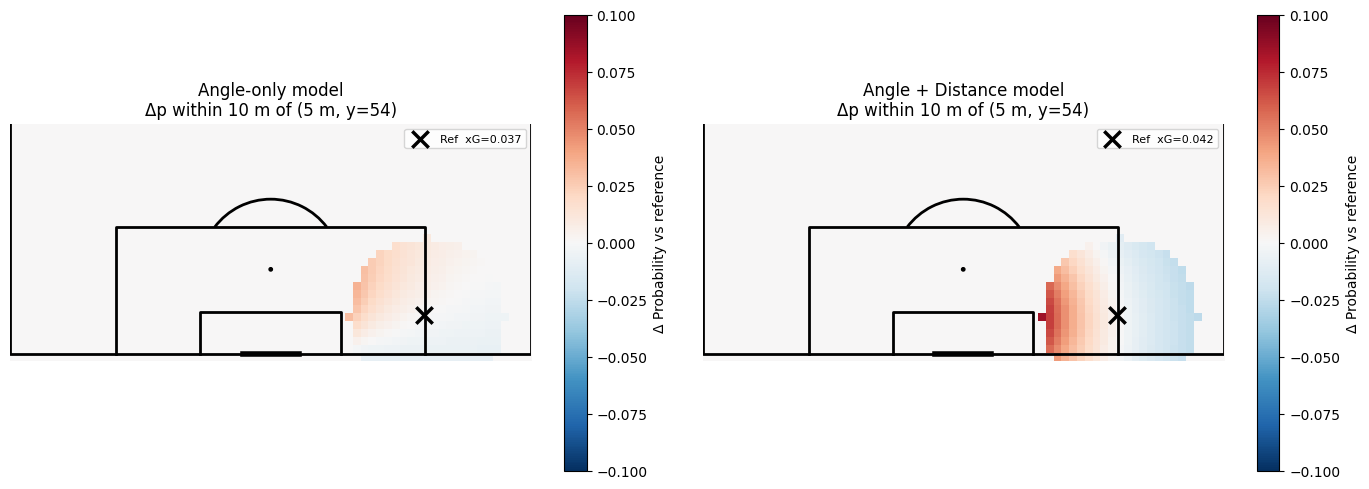

Reference position:  x=5 m from goal, y=54
Angle-only xG:       0.0365
Angle+Distance xG:   0.0422


In [41]:
# --- Probability change heatmap: angle-only vs angle+distance (final third) ---

# --- SET YOUR REFERENCE POINT HERE ---
ref_x = 5    # distance from goal line (metres)
ref_y = 54   # lateral position (0–68, centre = 34)
# --------------------------------------

FINAL_THIRD = 30   # grid rows covering the final third
MAX_DIFF    = 0.1  # colourbar capped at ±0.1
RADIUS      = 10   # only colour within this many metres of the reference point

# Build distance mask (same for both models)
xs = np.arange(FINAL_THIRD)
ys = np.arange(68)
xx, yy = np.meshgrid(xs, ys, indexing='ij')
dist_from_ref = np.sqrt((xx - ref_x)**2 + (yy - ref_y)**2)

def make_diff_ft(pgoal):
    ref_prob = pgoal[ref_x, ref_y]
    diff = (pgoal - ref_prob)[:FINAL_THIRD, :].copy()
    diff[dist_from_ref > RADIUS] = 0.0
    return ref_prob, diff

ref_prob_angle, diff_ft_angle = make_diff_ft(pgoal_2d_angle)
ref_prob_full,  diff_ft_full  = make_diff_ft(pgoal_2d_full)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, diff_ft, ref_prob, title in [
    (axes[0], diff_ft_angle, ref_prob_angle, 'Angle-only model'),
    (axes[1], diff_ft_full,  ref_prob_full,  'Angle + Distance model'),
]:
    pitch = VerticalPitch(
        line_color='black', half=True,
        pitch_type='custom', pitch_length=105, pitch_width=68,
        line_zorder=2
    )
    pitch.draw(ax=ax)

    hm = ax.imshow(
        diff_ft,
        extent=[-1, 68, FINAL_THIRD, -1],
        aspect='auto',
        cmap='RdBu_r',
        vmin=-MAX_DIFF,
        vmax=MAX_DIFF,
        zorder=1,
    )
    fig.colorbar(hm, ax=ax, label='\u0394 Probability vs reference')

    ax.scatter([ref_y], [ref_x], color='black', s=140, zorder=3,
               marker='x', linewidths=2.5,
               label=f'Ref  xG={ref_prob:.3f}')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_title(f'{title}\n\u0394p within {RADIUS} m of ({ref_x} m, y={ref_y})')
    ax.set_xlim((0, 68))
    ax.set_ylim((-1, FINAL_THIRD))
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

print(f'Reference position:  x={ref_x} m from goal, y={ref_y}')
print(f'Angle-only xG:       {ref_prob_angle:.4f}')
print(f'Angle+Distance xG:   {ref_prob_full:.4f}')


## SHAP Analysis
We now use the [SHAP](https://shap.readthedocs.io) library to compute exact Shapley values for the same logistic regression model. Unlike the contribution plot above (which uses $\\beta_j(x_{ij}-\\mu_j)$), SHAP values are computed via `LinearExplainer` on the log-odds scale, normalised around the model base value. We refit the model using scikit-learn so that SHAP can work with it directly.

In [42]:
# --- SHAP analysis of the logistic regression model ---
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Build feature matrix from the same model variables
X = shots[model_variables].values
y = shots['Goal'].values

# Scale features (improves convergence; SHAP values reflect scaled inputs)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit sklearn logistic regression with no regularisation,
# equivalent to the statsmodels GLM Binomial fit above
skl_model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
skl_model.fit(X_scaled, y)

# 200-shot background sample for the SHAP explainer
rng_shap = np.random.default_rng(0)
bg_idx = rng_shap.choice(len(X_scaled), size=200, replace=False)
X_bg = X_scaled[bg_idx]

# LinearExplainer gives exact SHAP values for linear models
explainer = shap.LinearExplainer(skl_model, X_bg, feature_perturbation='interventional')

# Explain the same 100-shot sample used in the contribution plot
shots_sample_shap = shots.sample(n=100, random_state=42)
X_sample = scaler.transform(shots_sample_shap[model_variables].values)
shap_values = explainer(X_sample)

# Beeswarm summary plot: x = SHAP value (impact on log-odds),
# colour = feature value (red = high, blue = low)
shap.plots.beeswarm(shap_values, feature_names=model_variables, show=True)


TypeError: beeswarm() got an unexpected keyword argument 'feature_names'

## SHAP Analysis
We now use the [SHAP](https://shap.readthedocs.io) library to compute exact Shapley values for the same logistic regression model. Unlike the contribution plot above (which uses $\\beta_j(x_{ij}-\\mu_j)$), SHAP values are computed via `LinearExplainer` on the log-odds scale, normalised around the model base value. We refit the model using scikit-learn so that SHAP can work with it directly.

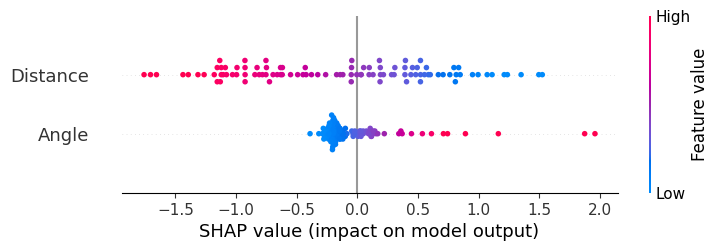

In [ ]:
# --- SHAP analysis of the logistic regression model ---
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Build feature matrix from the same model variables
X = shots[model_variables].values
y = shots['Goal'].values

# Scale features (improves convergence; SHAP values reflect scaled inputs)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit sklearn logistic regression with no regularisation,
# equivalent to the statsmodels GLM Binomial fit above
skl_model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
skl_model.fit(X_scaled, y)

# 200-shot background sample for the SHAP explainer
rng_shap = np.random.default_rng(0)
bg_idx = rng_shap.choice(len(X_scaled), size=200, replace=False)
X_bg = X_scaled[bg_idx]

# LinearExplainer gives exact SHAP values for linear models
explainer = shap.LinearExplainer(skl_model, X_bg, feature_perturbation='interventional')

# Explain the same 100-shot sample used in the contribution plot
shots_sample_shap = shots.sample(n=100, random_state=42)
X_sample = scaler.transform(shots_sample_shap[model_variables].values)
shap_values = explainer(X_sample)

# Attach feature names to the Explanation object
shap_values.feature_names = model_variables

# Beeswarm summary plot: x = SHAP value (impact on log-odds),
# colour = feature value (red = high, blue = low)
shap.plots.beeswarm(shap_values, show=True)
